In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from pff import reports_dir
from pff.data.data_empirical.json_schema import studies_from_sampled_targets
from pff.models.utils.callbacks_refactor import (
    _predictive_images_per_batch,
    _vpc_images_per_batch,
    sample_predictive_bundle,
    sample_vpc_bundle,
)
from pff.training.basic_experiment import BasicLightningExperiment
from pff.utils.plots.databatch_plot import plot_list_list_study_json,plot_aicme_databatch


In [7]:
experiment = BasicLightningExperiment.from_experiment_dir("/home/cesarali/Pharma/pff/results/faithful_valance_6141_")
#experiment = BasicLightningExperiment.from_experiment_comet(
#    "2a98913dcef6444caf29fc0ee4ce3843"
#)

# Option 1: load from a local experiment directory
# experiment = BasicLightningExperiment.from_experiment_dir(
#     "/home/cesarali/Pharma/pff/results/comet/functional-flow-pk/e19fb57257cd4501bcdb3a2294dc559e"
# )

# Option 2: load from Comet experiment id


#
model = experiment.model
dm = experiment.datamodule
dm.prepare_data()
dm.setup()
model_device = getattr(model, "device", None)

CometLogger will be initialized in online mode


In [27]:
same_dosing_loader = dm.get_synthetic_experiment_dataloader(
    n_targets=200,
    n_dosings=1,
    dosing_mode="repeated_dosing",
    dataset_size=1,
)
databatch_same_dosing = next(iter(same_dosing_loader))[0]

different_dosing_loader = dm.get_synthetic_experiment_dataloader(
    n_targets=200,
    n_dosings=1,
    dosing_mode="diverse_dosing",
    dataset_size=1,
)
databatch_different_dosing = next(iter(different_dosing_loader))[0]

if model_device is not None:
    databatch_same_dosing = databatch_same_dosing.to(model_device)
    databatch_different_dosing = databatch_different_dosing.to(model_device)

<Axes: xlabel='time', ylabel='concentration'>

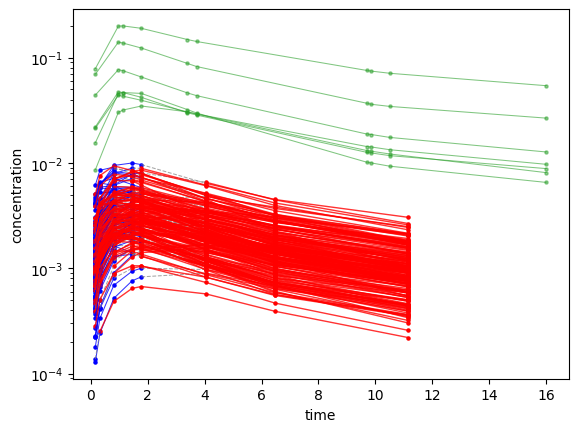

In [18]:
%matplotlib inline
plot_aicme_databatch(databatch_same_dosing)

In [ ]:
%matplotlib inline
plot_aicme_databatch(databatch_same_dosing)

In [28]:
sample_size = 100
samples, times, mask = model.sample_new_individual(databatch_different_dosing, sample_size=sample_size)

sampled_studies = [
    studies_from_sampled_targets(
        db=databatch_different_dosing,
        samples=samples,
        times=times,
        mask=mask,
        route_options=model.meta_dosing.route_options,
        dosing_time=float(model.meta_dosing.time),
    )
]


Sampling trajectories (new individual): 100%|███| 50/50 [00:01<00:00, 47.48it/s]


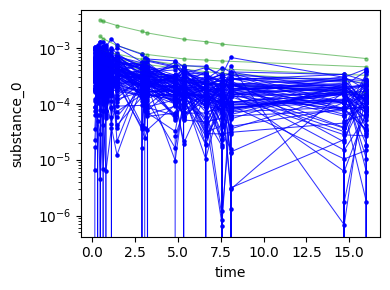

Saved sampled individuals plot(s): None


In [29]:

%matplotlib inline 
output_root = reports_dir / "notebooks_samples"
output_root.mkdir(parents=True, exist_ok=True)
sample_plot_path = output_root / "sampled_new_individuals.png"

sample_plot_paths = plot_list_list_study_json(
    studies=sampled_studies,
    file_name=None,
    number_of_rows=None,
    number_of_columns=1,
    log_scale=True,
    plot_all_separately=False,
)
print("Saved sampled individuals plot(s):", sample_plot_paths)
